# Test 1


$
L = 33 \text{cm}  \pm 2 \text{cm}
$



In [144]:
import polars as pl 
import matplotlib.pyplot as plt
import numpy as np
import altair as alt


Text(0, 0.5, '$a_{y} \\quad (\\text{m/s}^{2} )$')

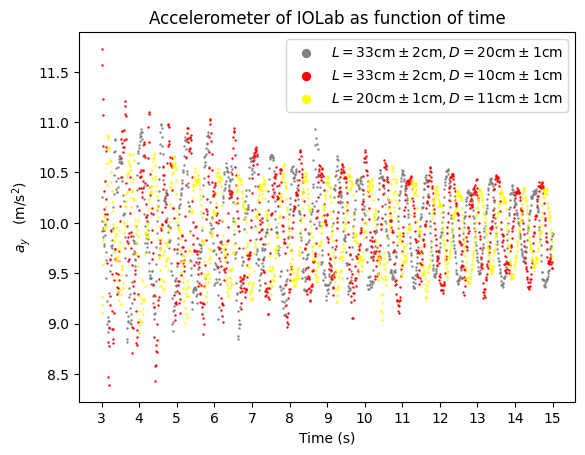

In [ ]:
MIN_TIME = 3 
MAX_TIME = 15

accel1 = pl.read_csv("eksperiment1/L33cmD20cm/sensor Accelerometer remote 1 Run1.csv", has_header=True, separator=';')
accel1 = accel1.slice(0, -1).filter(pl.col("Time (s)") > MIN_TIME)
accel1 = accel1.filter(pl.col("Time (s)") < MAX_TIME)

accel2 = pl.read_csv("eksperiment1/L33cmD20cm/sensor Accelerometer remote 1 Run2.csv", has_header=True, separator=';')
accel2 = accel2.slice(0,-1).filter(pl.col("Time (s)") > MIN_TIME)
accel2 = accel2.filter(pl.col("Time (s)") < MAX_TIME)

accel3 = pl.read_csv("eksperiment1/L33cmD20cm/sensor Accelerometer remote 1 Run3.csv", has_header=True, separator=';')
accel3 = accel3.slice(0,-1).filter(pl.col("Time (s)") > MIN_TIME)
accel3 = accel3.filter(pl.col("Time (s)") < MAX_TIME)


plt.scatter(
    x=accel1["Time (s)"],
    y=accel1["Ay (m/s²)"],
    c="gray",
    label = "$L = 33 \\text{cm} \\pm 2 \\text{cm}, D = 20 \\text{cm} \\pm 1 \\text{cm} $",
    s=0.5
)
plt.scatter(
    x=accel2["Time (s)"],
    y=accel2['Ay (m/s²)'],
    label = "$L = 33 \\text{cm} \\pm 2 \\text{cm}, D = 10 \\text{cm} \\pm 1 \\text{cm} $",
    c="red",
    s=0.5
)
plt.scatter(
    x=accel3["Time (s)"],
    y=accel3['Ay (m/s²)'],
    label = "$L = 20 \\text{cm} \\pm 1 \\text{cm}, D = 11 \\text{cm} \\pm 1 \\text{cm} $",
    c="yellow",
    s=0.5
)

plt.title("Accelerometer of IOLab as function of time")
plt.xlabel("Time (s)")
plt.xticks(np.arange(min(accel1['Time (s)']), max(accel1['Time (s)']) + 1, 1))
plt.legend(markerscale = 8)
plt.ylabel("$a_{y} \\quad (\\text{m/s}^{2} )$")


Individual g measurements:
shape: (163,)
Series: 'Time (s)' [f64]
[
	253.597359
	213.092225
	232.024805
	196.385795
	213.092225
	…
	39.037454
	9.256821
	9.256821
	11.539396
	2.884849
]

Calculated gravity:
g = 389.719 ± 2387.122 m/s²
Expected: 9.81 m/s²
Error: 379.909 m/s² (3872.67%)


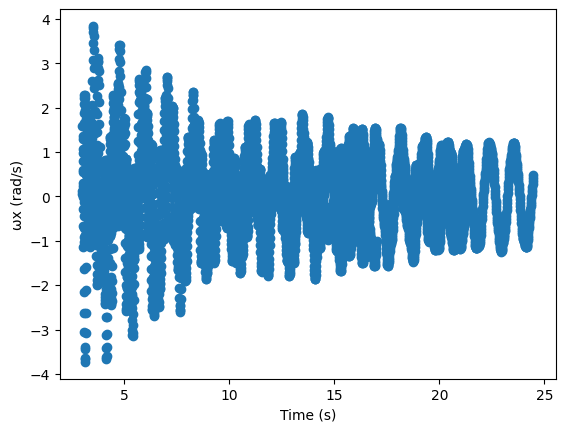

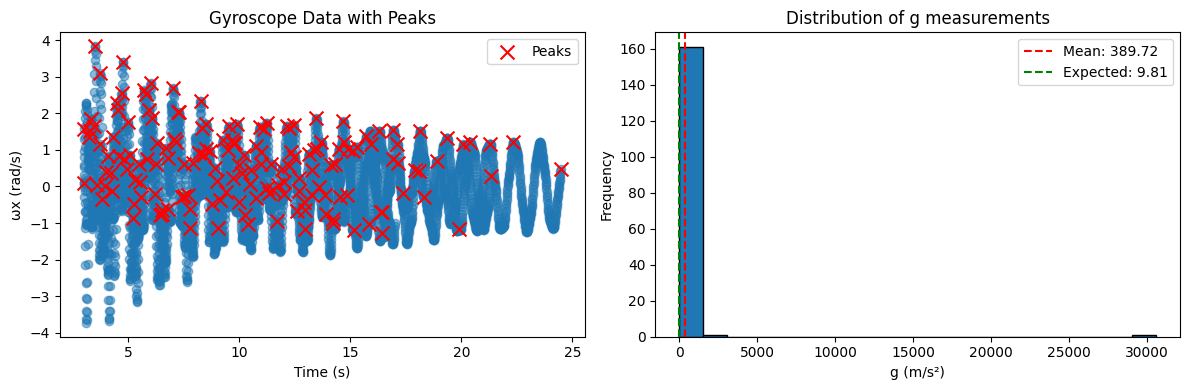

In [206]:
gyro = pl.read_csv("eksperiment1/L33cmD20cm/sensor Gyroscope remote 1 Run1.csv", has_header=True, separator=';').slice(0, -1)
gyro2 = pl.read_csv("eksperiment1/L33cmD20cm/sensor Gyroscope remote 1 Run2.csv", has_header=True, separator=';').slice(0, -1)
gyro3 = pl.read_csv("eksperiment1/L33cmD20cm/sensor Gyroscope remote 1 Run3.csv", has_header=True, separator=';').slice(0, -1)

gyro = gyro.extend(gyro2).extend(gyro3).filter(pl.col("Time (s)") > 3)

plt.scatter(
    x=gyro['Time (s)'],
    y=gyro['ωx (rad/s)'],
)
plt.xlabel('Time (s)')
plt.ylabel('ωx (rad/s)')
peaks = gyro.to_series(1).peak_max()

filtered = gyro.filter(peaks)



import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Your existing code...
gyro = pl.read_csv("eksperiment1/L33cmD20cm/sensor Gyroscope remote 1 Run1.csv", has_header=True, separator=';').slice(0, -1)
gyro2 = pl.read_csv("eksperiment1/L33cmD20cm/sensor Gyroscope remote 1 Run2.csv", has_header=True, separator=';').slice(0, -1)
gyro3 = pl.read_csv("eksperiment1/L33cmD20cm/sensor Gyroscope remote 1 Run3.csv", has_header=True, separator=';').slice(0, -1)
gyro = gyro.extend(gyro2).extend(gyro3).filter(pl.col("Time (s)") > 3)

# Find peaks
peaks = gyro.to_series(1).peak_max()
filtered = gyro.filter(peaks)

# Calculate periods between peaks
periods = filtered["Time (s)"].diff().drop_nulls()

# Pendulum length (from your folder name: L33cm)
L = 0.33  # meters

# Calculate gravity for each period
g_values = (4 * np.pi**2 * L) / (periods**2)

print("Individual g measurements:")
print(g_values)

# Calculate mean and standard deviation
g_mean = g_values.mean()
g_std = g_values.std()

print(f"\nCalculated gravity:")
print(f"g = {g_mean:.3f} ± {g_std:.3f} m/s²")
print(f"Expected: 9.81 m/s²")
print(f"Error: {abs(g_mean - 9.81):.3f} m/s² ({abs(g_mean - 9.81)/9.81*100:.2f}%)")

# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(x=gyro['Time (s)'], y=gyro['ωx (rad/s)'], alpha=0.5)
plt.scatter(x=filtered['Time (s)'], y=filtered['ωx (rad/s)'], 
            color='red', marker='x', s=100, label='Peaks')
plt.xlabel('Time (s)')
plt.ylabel('ωx (rad/s)')
plt.legend()
plt.title('Gyroscope Data with Peaks')

plt.subplot(1, 2, 2)
plt.hist(g_values, bins=20, edgecolor='black')
plt.axvline(g_mean, color='red', linestyle='--', label=f'Mean: {g_mean:.2f}')
plt.axvline(9.81, color='green', linestyle='--', label='Expected: 9.81')
plt.xlabel('g (m/s²)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of g measurements')

plt.tight_layout()
plt.show()